In [1]:
import tensorflow as tf
from tensorflow import keras

2026-02-08 18:23:36.593280: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-08 18:23:36.966859: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import numpy as np
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

In [3]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()

/home/josh/miniforge3/envs/ml-env/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [5]:
from keras import models
from keras import layers
from keras import initializers
from keras import activations

In [5]:
def createModel():
    model = models.Sequential()
    model.add(layers.Flatten(input_shape=[32, 32, 3]))
    for _ in range(20):
        model.add(layers.Dense(100, 
                            activation="elu", 
                            kernel_initializer="he_normal"))
    model.add(layers.Dense(10, activation="softmax"))
    return model

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full)

In [5]:
from keras import optimizers
from keras import callbacks

In [ ]:
learning_rates = [5e-5]
for lr in learning_rates:
    optimizer = optimizers.Nadam(learning_rate=lr)
    model = createModel()
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    log_dir = f"my_logs/lr_{lr}"
    tensorboard_cb = callbacks.TensorBoard(log_dir)
    
    history = model.fit(
        X_train, y_train,
        epochs=10,
        validation_data=(X_val, y_val),
        callbacks=[tensorboard_cb]
    )

Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.1707 - loss: 3.7471 - val_accuracy: 0.2258 - val_loss: 2.1455
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.2442 - loss: 2.0612 - val_accuracy: 0.2641 - val_loss: 1.9994
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.2753 - loss: 1.9603 - val_accuracy: 0.2918 - val_loss: 1.9256
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.3008 - loss: 1.8993 - val_accuracy: 0.3037 - val_loss: 1.8740
Epoch 5/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.3224 - loss: 1.8473 - val_accuracy: 0.3267 - val_loss: 1.8190
Epoch 6/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.3470 - loss: 1.7941 - val_accuracy: 0.3506 - val_loss: 1.7883
Epoch 7/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.3643 - loss: 1.7551 - val_accuracy: 0.3666 - val_loss: 1.7580
Epoch 8/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.3823 -

In [32]:
from keras import callbacks
from keras import optimizers

K = keras.backend

class ExponentialLearningRate(callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []
    def on_batch_end(self, batch, logs=None):
        lr = K.eval(self.model.optimizer.learning_rate)
        self.rates.append(K.eval(self.model.optimizer.learning_rate))
        self.losses.append(logs["loss"])
        self.model.optimizer.learning_rate.assign(lr * self.factor)

In [ ]:
optimizer = optimizers.Nadam(learning_rate=5e-4)
test_model = createModel()
test_model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
expon_lr = ExponentialLearningRate(factor=1.010)
test_history = test_model.fit(X_train_full, y_train_full, epochs=1,
                    validation_split=0.1, callbacks=[expon_lr])

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.1066 - loss: 449667.6562 - val_accuracy: 0.1058 - val_loss: 18.1759


Text(0, 0.5, 'Loss')

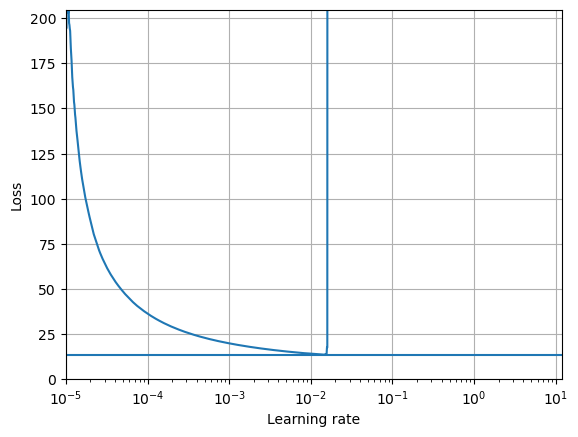

In [36]:
import matplotlib.pyplot as plt
plt.plot(expon_lr.rates, expon_lr.losses)
plt.gca().set_xscale('log')
plt.hlines(min(expon_lr.losses), min(expon_lr.rates), max(expon_lr.rates))
plt.axis([min(expon_lr.rates), max(expon_lr.rates), 0, expon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")

In [43]:
final_lr = 4e-5
nadam_opt = optimizers.Nadam(learning_rate=final_lr)
model = createModel()
model.compile(optimizer=nadam_opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

/home/josh/miniforge3/envs/ml-env/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
early_stopping_cb = callbacks.EarlyStopping(patience=10)
checkpoint_cb = callbacks.ModelCheckpoint("my_cifar_model.h5", save_best_only=True)
callbacks = [tensorboard_cb, early_stopping_cb, checkpoint_cb]
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, callbacks=callbacks)

Epoch 1/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.1508 - loss: 6.5867 - val_accuracy: 0.1901 - val_loss: 2.2993
Epoch 2/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.2174 - loss: 2.1568 - val_accuracy: 0.2455 - val_loss: 2.0788
Epoch 3/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.2631 - loss: 2.0196 - val_accuracy: 0.2774 - val_loss: 1.9733
Epoch 4/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.2950 - loss: 1.9417 - val_accuracy: 0.3024 - val_loss: 1.9275
Epoch 5/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.3168 - loss: 1.8840 - val_accuracy: 0.3281 - val_loss: 1.8643
Epoch 6/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.3336 - loss: 1.8399 - val_accuracy: 0.3461 - val_loss: 1.8152
Epoch 7/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.3514 - loss: 1.7965 - val_accuracy: 0.3538 - val_loss: 1.7970
Epoch 8/100
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 

In [45]:
X_new = X_train[:3]

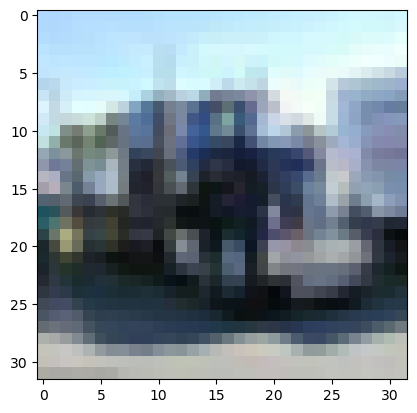

In [69]:
plt.imshow(X_new[2])

In [70]:
y_train[2]

array([9], dtype=uint8)

In [64]:
y_pred = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [60]:
y_pred_arr = np.array(y_pred)
indices = np.argmax(y_pred_arr, axis=1)

In [61]:
indices

array([4, 2, 9])

In [6]:
cifar_label_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [72]:
predicted_labels = [cifar_label_names[i] for i in indices]

In [73]:
predicted_labels

['deer', 'bird', 'truck']

In [76]:
def createModelBN():
    model = models.Sequential()
    model.add(layers.Flatten(input_shape=[32, 32, 3]))
    model.add(layers.BatchNormalization())
    for _ in range(20):
        model.add(layers.Dense(100, 
                            activation="elu", 
                            kernel_initializer="he_normal"))
        model.add(layers.BatchNormalization())
    model.add(layers.Dense(10, activation="softmax"))
    return model

In [78]:
final_lr = 4e-5
nadam_opt = optimizers.Nadam(learning_rate=final_lr)
model_BN = createModelBN()
model_BN.compile(optimizer=nadam_opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

/home/josh/miniforge3/envs/ml-env/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
from keras import callbacks
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10)
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_cifar_model.h5", save_best_only=True)
tensorboard_cb = keras.callbacks.TensorBoard("my_cifar_logs_bn")
callbacks = [tensorboard_cb, early_stopping_cb, checkpoint_cb]
history = model_BN.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, callbacks=callbacks)

NameError: name 'model_BN' is not defined

In [89]:
X_new = X_train[3:6]
y_true = y_train[3:6]
y_pred = model_BN.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [90]:
y_pred_class = np.argmax(y_pred, axis=1)

In [91]:
y_pred_labels = [cifar_label_names[i] for i in y_pred_class]

In [11]:
from keras import models
def createModelSelu():
    model = models.Sequential()
    model.add(layers.Flatten(input_shape=[32, 32, 3]))
    for _ in range(20):
        model.add(layers.Dense(100, 
                            activation="selu", 
                            kernel_initializer="lecun_normal"))
    model.add(layers.Dense(10, activation="softmax"))
    return model

In [12]:
from sklearn.preprocessing import StandardScaler
mean = X_train_full.mean(axis=0, keepdims=True)
std = X_train_full.std(axis=0, keepdims=True)

X_train_std = (X_train_full - mean) / std
X_test_std = (X_train_full - mean) / std

: 

In [10]:
model_selu = createModelSelu()

NameError: name 'models' is not defined

In [15]:
final_lr = 4e-5
nadam_opt = optimizers.Nadam(learning_rate=final_lr)
model_selu.compile(optimizer=nadam_opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [16]:
from keras import callbacks
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10)
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_cifar_model_selu.h5", save_best_only=True)
tensorboard_cb = keras.callbacks.TensorBoard("my_cifar_logs_selu")
history_selu = model_selu.fit(X_train_std, y_train, epochs=100, validation_split=0.2, callbacks=[early_stopping_cb, checkpoint_cb, tensorboard_cb])

Epoch 1/100
933/938 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2620 - loss: 2.1011

938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.3095 - loss: 1.9440 - val_accuracy: 0.3613 - val_loss: 1.8085
Epoch 2/100
934/938 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3785 - loss: 1.7496

938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.3919 - loss: 1.7147 - val_accuracy: 0.3953 - val_loss: 1.7097
Epoch 3/100
937/938 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4228 - loss: 1.6275

KeyboardInterrupt: 